In [34]:
import collections
import matplotlib.pyplot as plt
import random

We calculate and normalize the frequency of fragment lengths from the BED file.

In [35]:
def compute_normalized_length_distribution(bed_path):
    # 1. Read file and compute lengths
    lengths = []
    with open(bed_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            try:
                start = int(parts[1])
                end   = int(parts[2])
            except ValueError:
                # skip header or malformed lines
                continue
            lengths.append(end - start)

    # 2. Count occurrences of each length
    freq = collections.Counter(lengths)

    # 3. Normalize counts
    total = sum(freq.values())
    lengths_sorted = sorted(freq)
    norm_freq = [freq[l] / total for l in lengths_sorted]

    return lengths_sorted, norm_freq

We visualize the normalized frequency with fragment length on the X-axis.

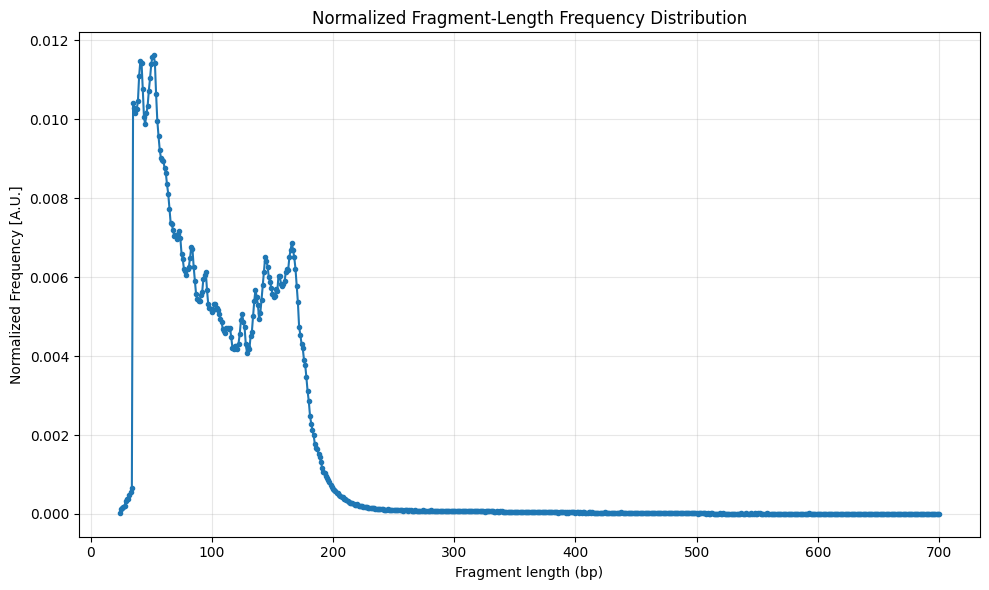

In [36]:
def plot_distribution(lengths, norm_freq):
    plt.figure(figsize=(10, 6))
    plt.plot(lengths, norm_freq, marker='.', linestyle='-')
    plt.xlabel('Fragment length (bp)')
    plt.ylabel('Normalized Frequency [A.U.]')
    plt.title('Normalized Fragment-Length Frequency Distribution')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    bed_file = "query.bed"
    lengths, norm_freq = compute_normalized_length_distribution(bed_file)
    plot_distribution(lengths, norm_freq)

**Rescaling:**


We load the reference histogram containing normalized frequencies by length.

In [37]:
def load_ref_hist(path):
    ref_norm = {}
    with open(path) as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) != 2:
                continue
            try:
                length = int(parts[0])
                freq   = float(parts[1])
            except ValueError:
                continue
            ref_norm[length] = freq

    total = sum(ref_norm.values())
    return ref_norm

We count the fragment lengths from query.bed and save them for subsampling.

In [38]:
def compute_norm(counter):
    total = sum(counter.values())
    return {L: cnt/total for L, cnt in counter.items()}

def compute_query_lengths(bed_path):
    mode   = "rt"
    qcnt = collections.Counter()
    records = []

    with open(bed_path, mode) as fh:
        for line in fh:
            parts = line.rstrip().split()
            if len(parts) < 3:
                continue
            try:
                start = int(parts[1])
                end   = int(parts[2])
            except ValueError:
                continue
            L = end - start
            qcnt[L] += 1
            records.append((L, line))
    return qcnt, records

We calculate per-length sampling probabilities to match the query to the reference and also write a new BED file keeping lines with probability proportional to reference.

In [39]:
def compute_sampling_probs(ref_norm, query_norm):
    probs = {}
    for L, fq in query_norm.items():
        fr = ref_norm.get(L, 0.0)
        probs[L] = min(1.0, fr / fq) if fq > 0 else 0.0
    return probs

def subsample(records, probs, out_bed):
    kept = 0
    with open(out_bed, "w") as out:
        for L, line in records:
            if random.random() <= probs.get(L, 0.0):
                out.write(line)
                kept += 1
    return kept

We plot and compare reference, original query, and rescaled distributions.

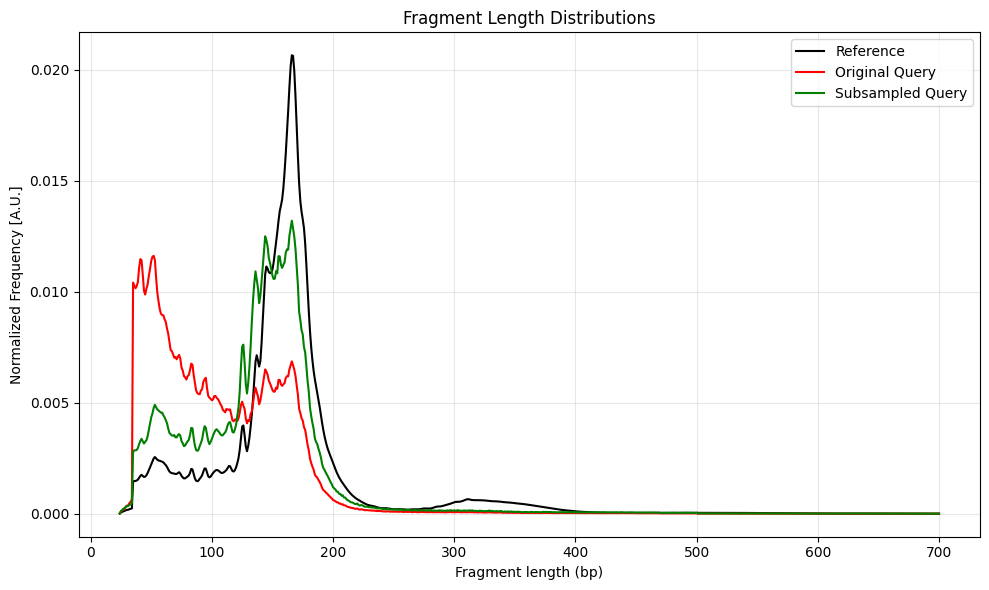

In [40]:
def main():
    # Load reference (already normalized frequencies)
    ref_norm = load_ref_hist("reference.hist")

    # Load your decompressed query.bed (plain text)
    query_cnt, records = compute_query_lengths("query.bed")
    query_norm = compute_norm(query_cnt)
    probs = compute_sampling_probs(ref_norm, query_norm)
    subsample(records, probs, "query.subsampled.bed")
    subs_cnt, _ = compute_query_lengths("query.subsampled.bed")
    subs_norm = compute_norm(subs_cnt)
    plot_distributions(ref_norm, query_norm, subs_norm)


if __name__ == "__main__":
    main()